In [ ]:
# black-sholes, vanna-volga

In [ ]:
%pip install scipy

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [ ]:
# -*- coding: utf-8 -*-
import math
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import yfinance as yf
from scipy.stats import norm
from scipy.optimize import brentq


# =========================
# ПАРАМЕТРЫ
# =========================
TICKER = "SPY"
N_EXPIRATIONS = 3          # сколько экспираций обрабатывать
HIST_VOL_LOOKBACK = "1y"   # период для исторической волатильности
TRADING_DAYS = 252         # торговых дней в году
MIN_BID = 0.0              # можно отсечь "мусорные" котировки, если хотите
USE_YF_IV_IF_AVAILABLE = True  # оставить колонку с IV из Yahoo для сравнения


# =========================
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# =========================
def yearfrac_365_25(t_end_utc: datetime) -> float:
    """Годовая доля между сейчас и моментом t_end_utc в UTC."""
    now = datetime.now(timezone.utc)
    dt = (t_end_utc - now).total_seconds()
    return max(dt, 0.0) / (365.25 * 24 * 3600.0)


def bs_price(S, K, r, T, sigma, option_type: str) -> float:
    """Теоретическая цена Black–Scholes (европейский call/put)."""
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        # граничные случаи
        if option_type == "call":
            return max(0.0, S - K * math.exp(-r * T))
        else:
            return max(0.0, K * math.exp(-r * T) - S)

    d1 = (math.log(S / K) + (r + 0.5 * sigma * sigma) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    if option_type == "call":
        return S * norm.cdf(d1) - K * math.exp(-r * T) * norm.cdf(d2)
    else:
        return K * math.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)


def implied_vol_from_price(S, K, r, T, market_price, option_type: str,
                           sigma_lo=1e-6, sigma_hi=5.0):
    """Находит имплайдную волу через корень (теор. цена - рыночная mid = 0)."""
    if market_price is None or market_price <= 0 or T <= 0:
        return np.nan

    # Проверим значения на концах отрезка
    def f(sig):
        return bs_price(S, K, r, T, sig, option_type) - market_price

    try:
        f_lo = f(sigma_lo)
        f_hi = f(sigma_hi)
        # Если на концах знак не различается — расширим верхнюю границу
        if f_lo * f_hi > 0:
            for x in [10.0, 15.0]:
                if f(sigma_lo) * f(x) <= 0:
                    sigma_hi = x
                    break
        # Финальный брутфорс корня
        return brentq(f, sigma_lo, sigma_hi, maxiter=200, xtol=1e-8)
    except Exception:
        return np.nan


# =========================
# ДАННЫЕ: СПОТ, СТАВКА, HV
# =========================
spy = yf.Ticker(TICKER)
spot = float(spy.history(period="1d")["Close"].iloc[-1])

# Безрисковая ставка: возьмём 13-недельный T-Bill (^IRX), годовая %. Делим на 100.
try:
    r_annual = float(yf.Ticker("^IRX").history(period="5d")["Close"].dropna().iloc[-1]) / 100.0
except Exception:
    # fallback: 3-месячные ноты могут быть недоступны, попробуем 10-летние (^TNX)
    r_annual = float(yf.Ticker("^TNX").history(period="5d")["Close"].dropna().iloc[-1]) / 100.0

# Историческая волатильность (лог-доходности за год, дневная std * sqrt(252))
hist = spy.history(period=HIST_VOL_LOOKBACK)["Close"].dropna()
logret = np.log(hist / hist.shift(1)).dropna()
hv_annual = float(logret.std() * np.sqrt(TRADING_DAYS))

# =========================
# ОПЦИОНЫ: ЧТЕНИЕ И РАСЧЁТЫ
# =========================
expirations = spy.options
expirations = expirations[-N_EXPIRATIONS:] if N_EXPIRATIONS else expirations

rows = []

for exp_str in expirations:
    chain = spy.option_chain(exp_str)
    for opt_type, df in (("call", chain.calls), ("put", chain.puts)):
        # На Yahoo колонка impliedVolatility уже есть (в долях, не в %)
        for _, row in df.iterrows():
            K = float(row["strike"])
            bid = float(row.get("bid", np.nan))
            ask = float(row.get("ask", np.nan))
            last = float(row.get("lastPrice", np.nan))
            yf_iv = float(row.get("impliedVolatility", np.nan)) if USE_YF_IV_IF_AVAILABLE else np.nan

            # Mid: если bid/ask валидные, иначе fallback к last
            if np.isfinite(bid) and np.isfinite(ask) and bid >= MIN_BID and ask > 0:
                mid = (bid + ask) / 2.0
            elif np.isfinite(last) and last > 0:
                mid = last
            else:
                mid = np.nan

            # Время до экспирации в годах (UTC)
            exp_dt_utc = datetime.strptime(exp_str + " 20:00:00", "%Y-%m-%d %H:%M:%S").replace(tzinfo=timezone.utc)
            T = yearfrac_365_25(exp_dt_utc)
            if T <= 0:
                continue

            # Теоретическая цена на исторической воле
            theo_hv = bs_price(spot, K, r_annual, T, hv_annual, opt_type)

            # Имплайдная вола из mid
            iv_mid = implied_vol_from_price(spot, K, r_annual, T, mid, opt_type) if np.isfinite(mid) else np.nan

            # Теоретическая цена на IV (для контроля; будет ~ равна mid, если корень нашёлся)
            theo_iv = bs_price(spot, K, r_annual, T, iv_mid, opt_type) if np.isfinite(iv_mid) else np.nan

            edge_hv_vs_mid = (theo_hv - mid) if np.isfinite(theo_hv) and np.isfinite(mid) else np.nan

            rows.append({
                "expiration": exp_str,
                "type": opt_type,
                "strike": K,
                "bid": bid if np.isfinite(bid) else np.nan,
                "ask": ask if np.isfinite(ask) else np.nan,
                "mid": mid if np.isfinite(mid) else np.nan,
                "last": last if np.isfinite(last) else np.nan,
                "spot": spot,
                "r": r_annual,
                "T_years": T,
                "HV_annual": hv_annual,
                "BS_theo_HV": theo_hv,
                "IV_from_mid": iv_mid,
                "BS_theo_IV": theo_iv,
                "edge_HV_minus_mid": edge_hv_vs_mid,
                "YF_IV": yf_iv
            })

table = pd.DataFrame(rows)
table

In [ ]:
pd.options.display.float_format = '{:.4f}'.format


In [ ]:
bl = table[table["type"] == "put"][table["expiration"] == "2028-01-21"][["expiration", "strike", "spot", "mid", "BS_theo_HV"]]

bl["good_rate"] = bl["BS_theo_HV"] / bl["mid"]
bl["bad_abs"] = bl["mid"] - bl["BS_theo_HV"]

bl["stike_pct"] = bl["strike"] / bl["spot"]

/tmp/ipykernel_33633/437917260.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  bl = table[table["type"] == "put"][table["expiration"] == "2028-01-21"][["expiration", "strike", "spot", "mid", "BS_theo_HV"]]


In [ ]:
%pip install matplotlib

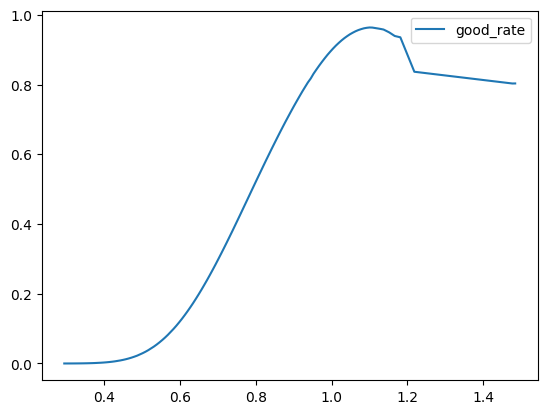

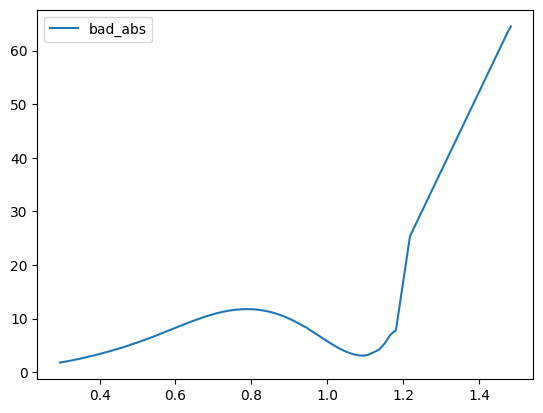

In [37]:
import matplotlib.pyplot as plt

plt.plot(bl["stike_pct"], bl["good_rate"], label="good_rate")
plt.legend()
plt.show()

plt.plot(bl["stike_pct"], bl["bad_abs"], label="bad_abs")
plt.legend()
plt.show()

In [39]:
table[table["type"] == "put"][table["expiration"] == "2028-01-21"]

/tmp/ipykernel_33633/3826136567.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  table[table["type"] == "put"][table["expiration"] == "2028-01-21"]


,expiration,type,strike,bid,ask,mid,last,spot,r,T_years,HV_annual,BS_theo_HV,IV_from_mid,BS_theo_IV,edge_HV_minus_mid,YF_IV
699,2028-01-21,put,200.0000,1.7900,1.8200,1.8050,1.7900,677.2500,0.0376,2.2422,0.1955,0.0001,0.4329,1.8050,-1.8049,0.4063
700,2028-01-21,put,205.0000,1.8400,1.9100,1.8750,2.0000,677.2500,0.0376,2.2422,0.1955,0.0001,0.4276,1.8750,-1.8749,0.4016
701,2028-01-21,put,210.0000,1.9300,2.0100,1.9700,2.0000,677.2500,0.0376,2.2422,0.1955,0.0002,0.4233,1.9700,-1.9698,0.3972
702,2028-01-21,put,215.0000,2.0300,2.1100,2.0700,2.3000,677.2500,0.0376,2.2422,0.1955,0.0003,0.4191,2.0700,-2.0697,0.3928
703,2028-01-21,put,220.0000,2.1300,2.2100,2.1700,2.4800,677.2500,0.0376,2.2422,0.1955,0.0004,0.4148,2.1700,-2.1696,0.3884
704,2028-01-21,put,225.0000,2.2400,2.3200,2.2800,2.6000,677.2500,0.0376,2.2422,0.1955,0.0006,0.4109,2.2800,-2.2794,0.3842
705,2028-01-21,put,230.0000,2.3500,2.4300,2.3900,2.7500,677.2500,0.0376,2.2422,0.1955,0.0009,0.4069,2.3900,-2.3891,0.3800
706,2028-01-21,put,235.0000,2.4600,2.5400,2.5000,2.8200,677.2500,0.0376,2.2422,0.1955,0.0012,0.4029,2.5000,-2.4988,0.3758
707,2028-01-21,put,240.0000,2.5800,2.6600,2.6200,3.0500,677.2500,0.0376,2.2422,0.1955,0.0017,0.3992,2.6200,-2.6183,0.3718
708,2028-01-21,put,245.0000,2.6900,2.7700,2.7300,3.2600,677.2500,0.0376,2.2422,0.1955,0.0023,0.3951,2.7300,-2.7277,0.3676
